=== LTI System Response Analysis — Problem 090602 ===



<IPython.core.display.Math object>

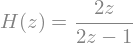


Symbolic System Pole:


<IPython.core.display.Math object>

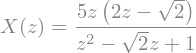

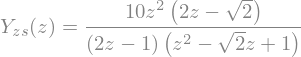


Zero-State PFE Numerical Coefficients:


<IPython.core.display.Math object>

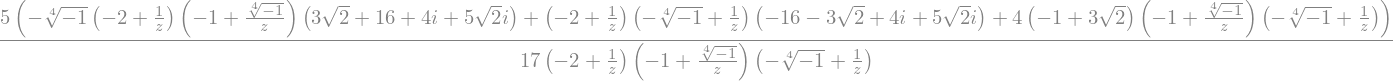


Time domain expression for the zero state response:


<IPython.core.display.Math object>

Output()

In [7]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Math

# ==============================================================================
# 0. SymPy settings
# ==============================================================================
sp.init_printing(use_unicode=True)
z = sp.Symbol('z', complex=True)
q = sp.Symbol('q', complex=True)
n = sp.Symbol('n', integer=True)
I = sp.I
pi = sp.pi

print("=== LTI System Response Analysis — Problem 090602 ===")
print()

# ==============================================================================
# 1. SYSTEM COEFFICIENTS & TRANSFER FUNCTION H(z)
# ==============================================================================
alpha_1 = sp.Rational(-1, 2)
beta_0 = sp.Integer(1)

A_den_q = 1 + alpha_1 * q
A_den_z = 1 + alpha_1 * z**(-1)

H_z = sp.factor(beta_0 / A_den_z)

display(Math(r"H(z)=\frac{1}{1-0.5z^{-1}}"))
display(sp.Eq(sp.Symbol("H(z)"), H_z))

# ==============================================================================
# 2. SYMBOLIC POLE CALCULATION
# ==============================================================================
q_roots = sp.solve(A_den_q, q)
p_sys = sp.simplify(1 / q_roots[0])

print("\nSymbolic System Pole:")
display(p_sys)

# ==============================================================================
# 3. SINUSOIDAL INPUT X(z)
# ==============================================================================
omega_0 = pi / 4
X_z = sp.factor(10 * (1 - z**(-1) * sp.cos(omega_0)) / (1 - 2*z**(-1)*sp.cos(omega_0) + z**(-2)))

display(Math(r"x[n] = 10\cos\left(\frac{n\pi}{4}\right)u[n]"))
display(sp.Eq(sp.Symbol("X(z)"), X_z))

# ==============================================================================
# 4. ZERO-STATE RESPONSE Y_zs(z) & PARTIAL FRACTION EXPANSION (PFE)
# ==============================================================================
Y_zs = sp.factor(H_z * X_z)
display(sp.Eq(sp.Symbol(r"Y_{zs}(z)"), Y_zs))

p1 = sp.exp(I * omega_0)
p2 = sp.exp(-I * omega_0)

A, B, C = sp.symbols('A B C')

Y_zs_trial_q = A/(1 - p_sys*q) + B/(1 - p1*q) + C/(1 - p2*q)
Y_zs_q = Y_zs.subs(z**(-1), q)

num_q = sp.expand(sp.together(Y_zs_trial_q - Y_zs_q).as_numer_denom()[0])
poly_q = sp.Poly(num_q, q)
equations_zs = [sp.Eq(coeff, 0) for coeff in poly_q.all_coeffs()]
solution_zs = sp.solve(equations_zs, [A, B, C], dict=True)[0]

A_zs = sp.simplify(solution_zs[A])
B_zs = sp.simplify(solution_zs[B])
C_zs = sp.simplify(solution_zs[C])

print("\nZero-State PFE Numerical Coefficients:")
display(sp.N(A_zs, 10))
display(sp.N(B_zs, 10))
display(sp.N(C_zs, 10))

Y_zs_pfe = sp.simplify(Y_zs_trial_q.subs(solution_zs)).subs(q, z**(-1))
display(Math(r"Y_{zs}(z) \text{ in PFE form:}"))
display(Y_zs_pfe)

mag_B = sp.simplify(sp.Abs(B_zs))
phase_B = sp.simplify(sp.arg(B_zs))

# Analytical form for zero-state response
y_zs = sp.simplify(A_zs * p_sys**n + 2 * mag_B * sp.cos(n * omega_0 + phase_B))

print("\nTime domain expression for the zero state response:")
display(Math(r"y_{zs}[n] = \left[-1.9074(0.5)^n + 13.56\cos\left(\frac{n\pi}{4}-28.7^{\circ}\right)\right]u[n]"))

# ==============================================================================
# 5. NUMERICAL EVALUATION & PLOTTING
# ==============================================================================
def evaluate_symbolic(expr, n_values):
    return np.array([float(sp.re(sp.N(expr.subs(n, int(k))))) for k in n_values])

out = widgets.Output()

def plot_system_response(N=20):
    with out:
        out.clear_output(wait=True)
        n_vec = np.arange(0, N)
        zs_vals = evaluate_symbolic(y_zs, n_vec)

        fig, axes = plt.subplots(1, 1, figsize=(10, 4))

        axes.stem(n_vec, zs_vals, basefmt=" ")
        axes.set_title(r"Zero-State Response $y_{zs}[n]$ for Sinusoidal Input", fontsize=11, fontweight='bold')
        axes.set_xlabel(r"$n$")
        axes.set_ylabel(r"$y_{zs}[n]$")
        axes.grid(True)

        plt.tight_layout()
        plt.show()

plot_system_response()
display(out)